In [4]:
import pandas as pd

df = pd.read_csv('data/train.csv')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

## 1. Анализ целевой переменной

Распределение значений TARGET:
TARGET
0    73012
1     3008
Name: count, dtype: int64

Доли классов:
TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64


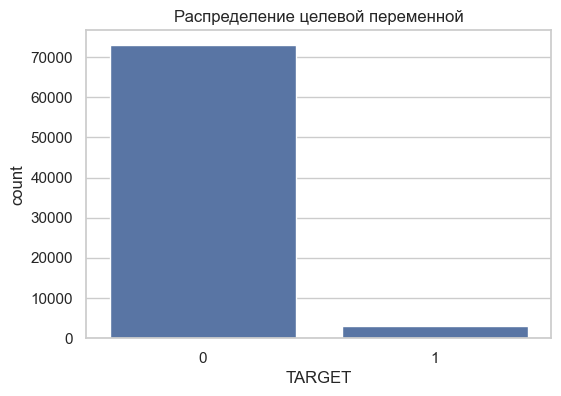

In [6]:
# 1. Анализ целевой переменной
target_col = 'TARGET'

# Численный анализ
print(f"Распределение значений {target_col}:")
print(df[target_col].value_counts())
print(f"\nДоли классов:")
print(df[target_col].value_counts(normalize=True))

# Визуализация
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title('Распределение целевой переменной')
plt.show()

# Проверка на наличие временных признаков
# Если бы были временные метки, мы бы построили график зависимости среднего таргета от времени.
# В данном датасете, судя по описанию, только численные признаки.

## 2. Анализ признаков

In [14]:
# 2. Анализ признаков

# Типизация и пропуски
print("Информация о данных:")
print(df.info())

print("\nПропущенные значения:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Пропущенных значений не найдено.")

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB
None

Пропущенные значения:
Пропущенных значений не найдено.


In [15]:
# Определение важности признаков и выбор топ-6
# Вычисляем корреляцию всех признаков с таргетом
target_corr = df.corrwith(df[target_col])
target_corr_abs = target_corr.abs().sort_values(ascending=False)

# Выбираем топ-6 признаков (исключая сам таргет, который идет первым)
top_6_features = target_corr_abs.index[1:7].tolist()

print("Топ-6 признаков по корреляции с таргетом:")
print(target_corr[top_6_features])

# Сохраним список для дальнейшей визуализации
features_to_plot = top_6_features

c:\Users\DELL\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\DELL\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Топ-6 признаков по корреляции с таргетом:
ind_var30             -0.149811
num_meses_var5_ult3   -0.148253
num_var30             -0.138289
num_var42             -0.135693
ind_var5              -0.135349
num_var5              -0.134095
dtype: float64


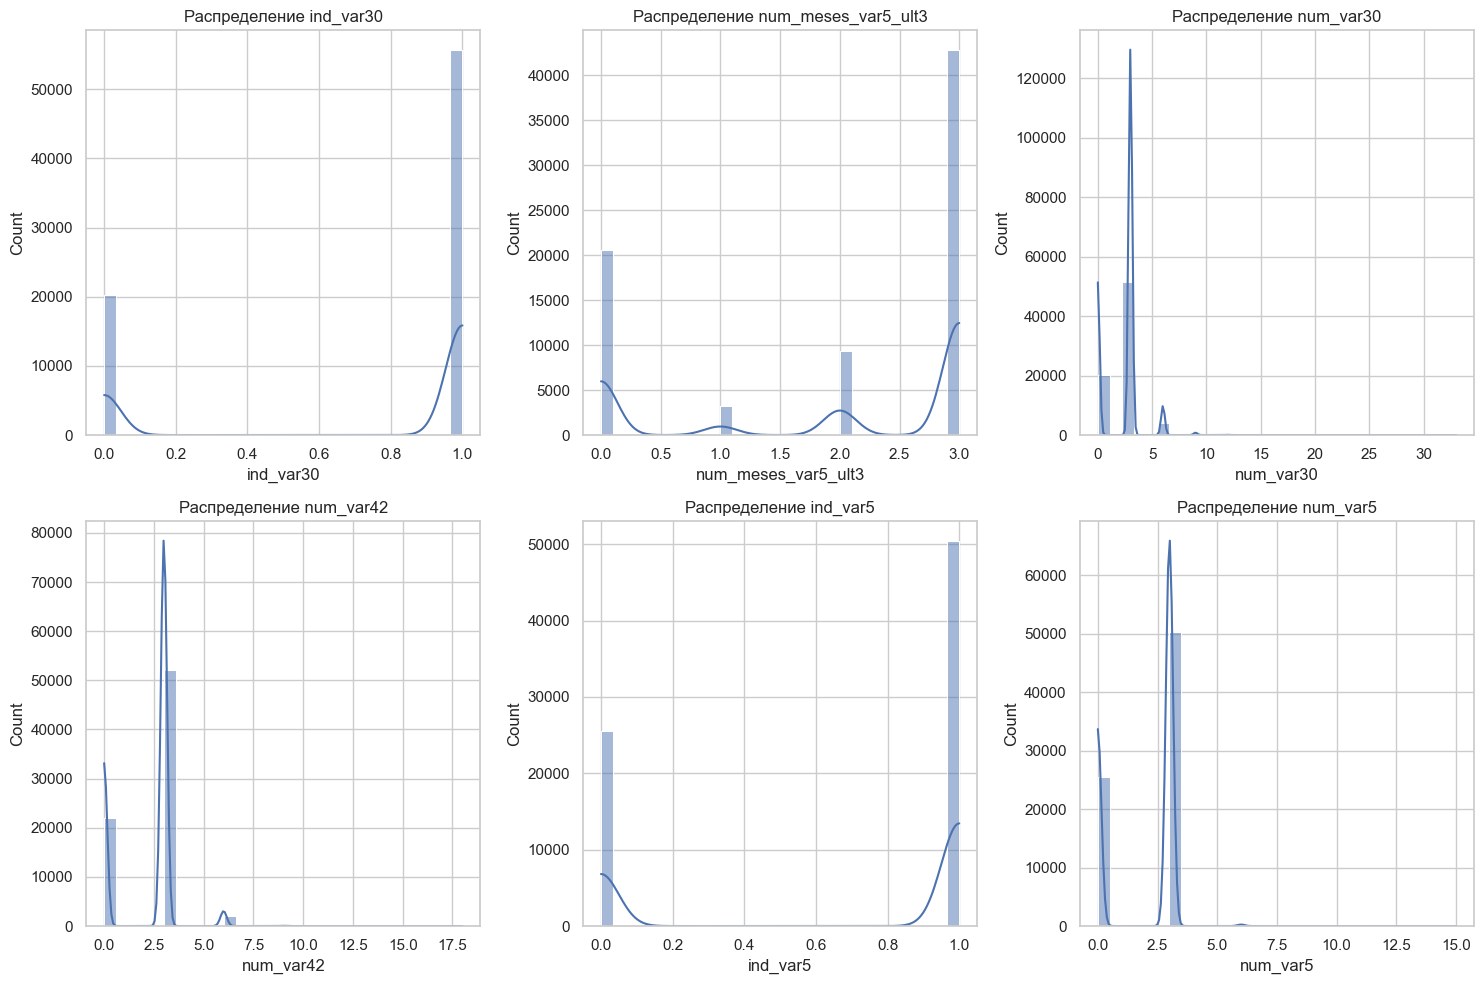

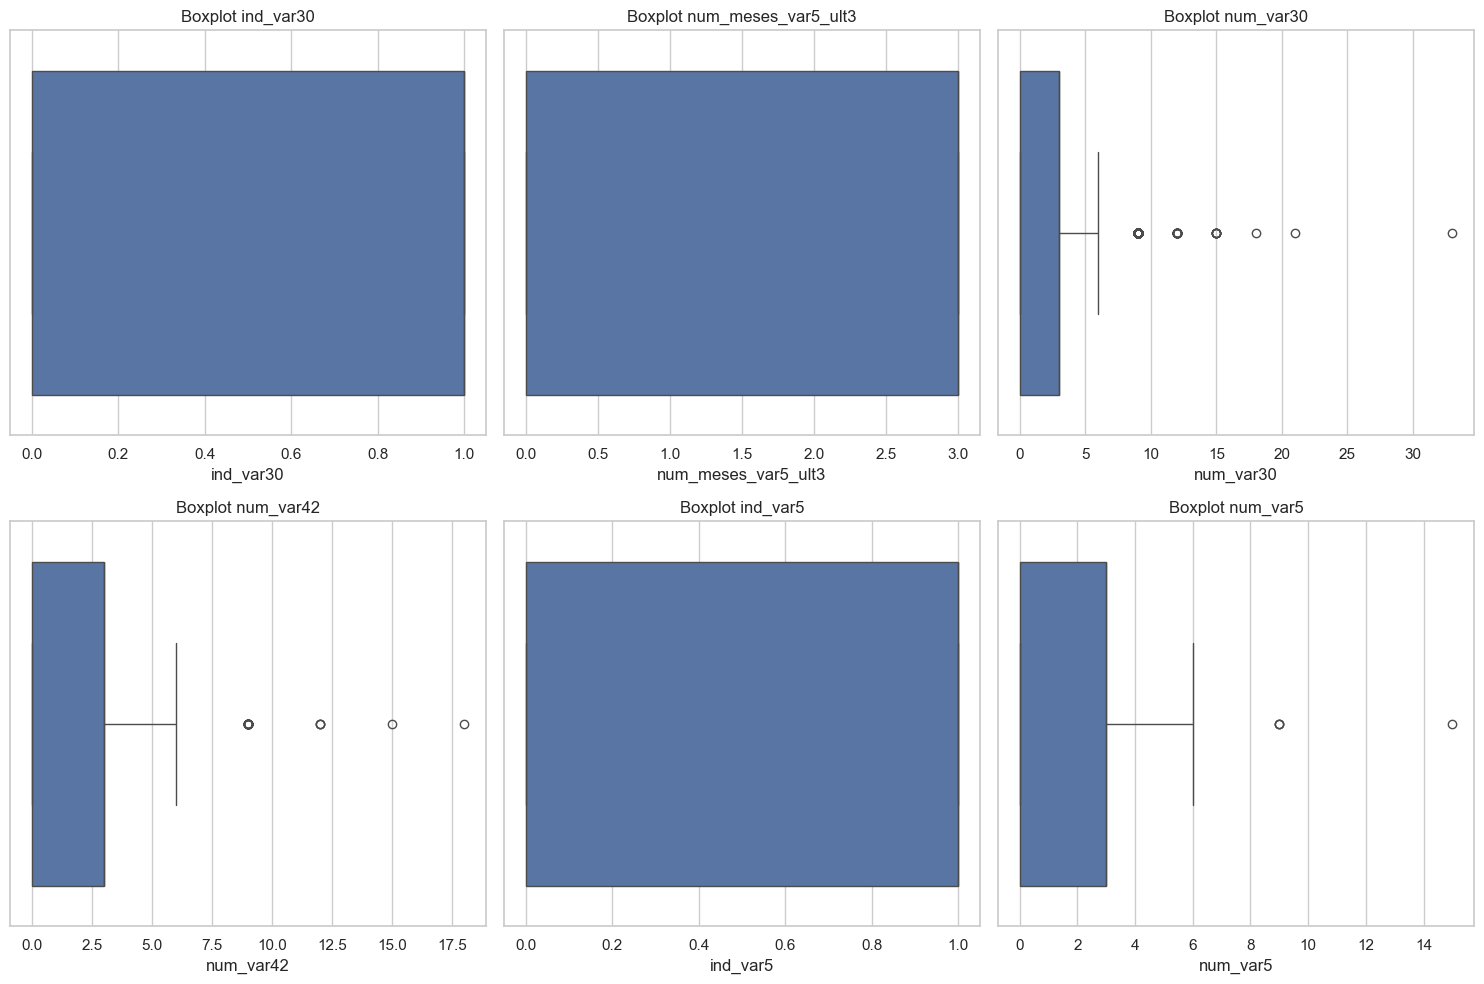

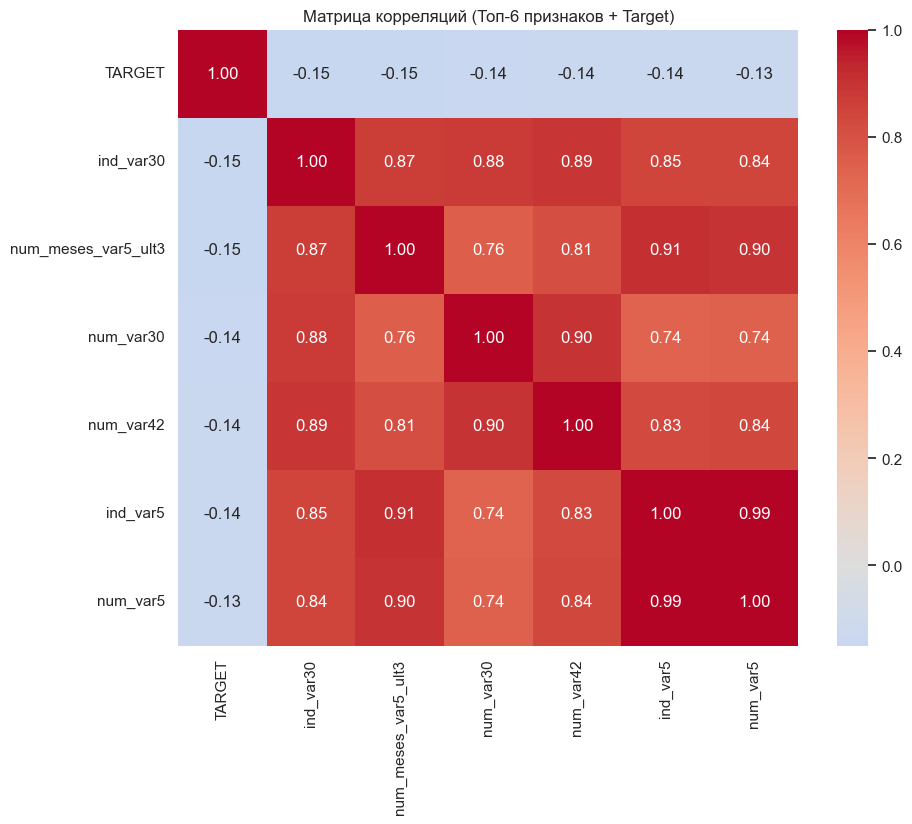

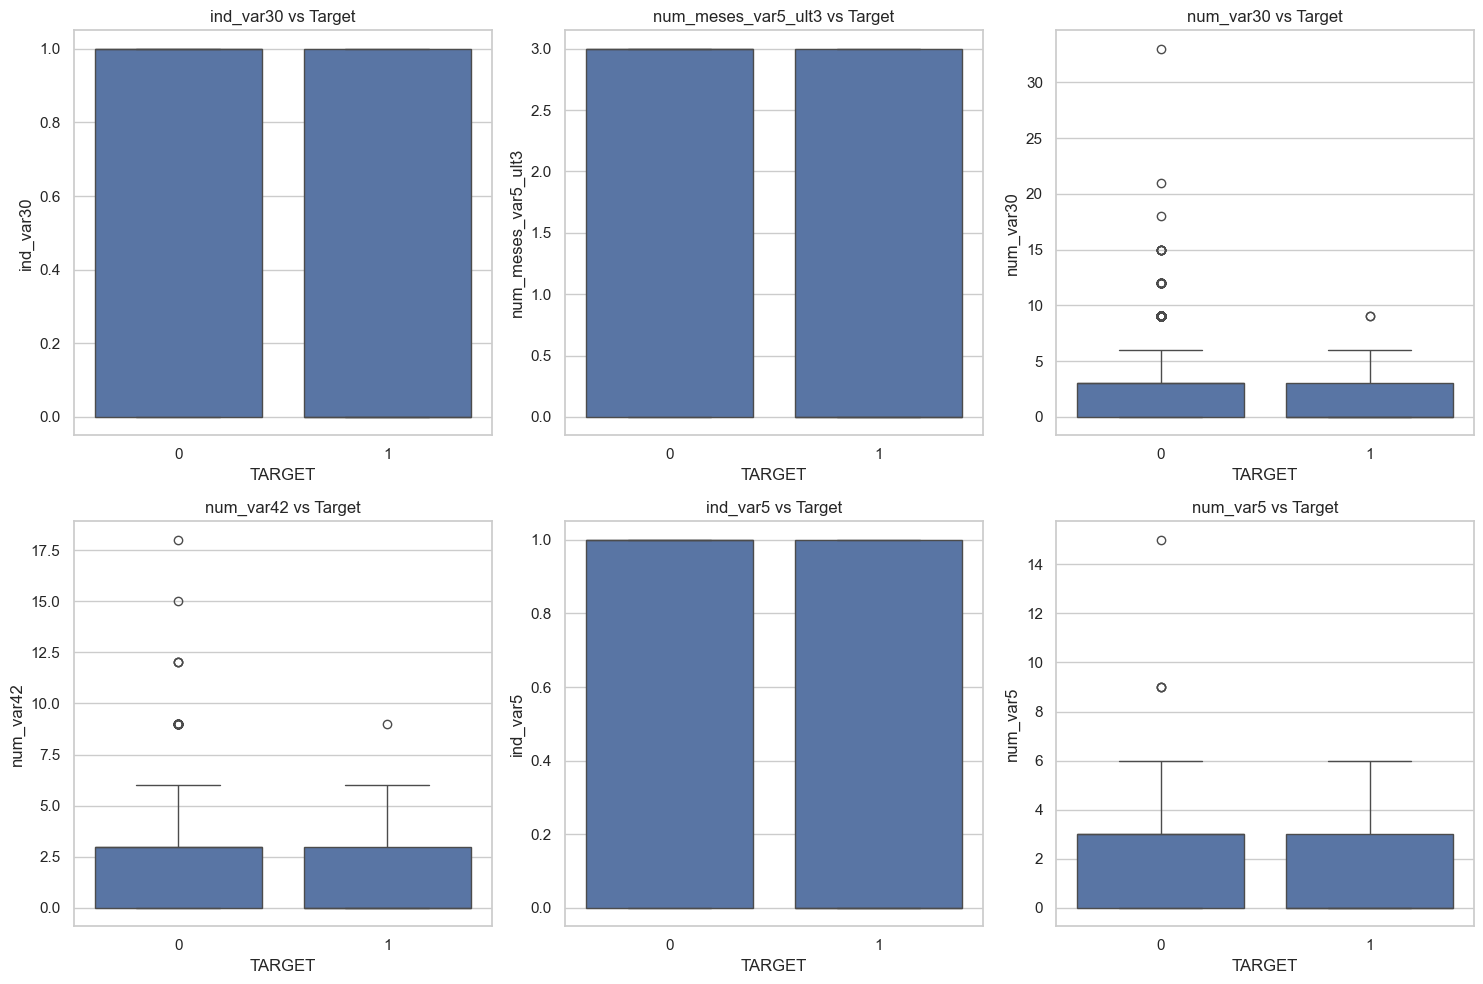

In [16]:
# Визуализация для топ-6 признаков

# 1. Распределения
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

# 2. Boxplots (выбросы)
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# 3. Матрица корреляций (только для топ-6 + таргет)
plt.figure(figsize=(10, 8))
cols_for_heatmap = [target_col] + features_to_plot
corr_matrix_top = df[cols_for_heatmap].corr()
sns.heatmap(corr_matrix_top, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Матрица корреляций (Топ-6 признаков + Target)')
plt.show()

# 4. Зависимость от таргета (Boxplots для каждого класса)
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f'{col} vs Target')
plt.tight_layout()
plt.show()